# 久期计算结果验证分析

本notebook用于验证通过模型计算的基金久期与Wind披露的真实久期之间的差异。

In [3]:
from WindPy import w
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 启动Wind
w.start()
print("Wind连接成功")

Wind连接成功


In [4]:
# 加载计算结果
result_df = pd.read_excel('./output/久期详细结果_linear_20251231.xlsx')
result_df = result_df.rename(columns={'Unnamed: 0': 'fund_code'})

print(f"总基金数量: {len(result_df)}")
print(f"\n基金类型分布:")
print(result_df['fund_type'].value_counts())
print(f"\n债券类型分布:")
print(result_df['bond_type'].value_counts())

result_df.head()

总基金数量: 1564

基金类型分布:
fund_type
medium_long    1213
short           351
Name: count, dtype: int64

债券类型分布:
bond_type
credit    1212
rate       352
Name: count, dtype: int64


,fund_code,duration,fund_type,bond_type,name
0,000084.OF,1.375068,short,credit,博时安盈A
1,000089.OF,0.720912,short,credit,民生加银高等级信用债C
2,000128.OF,2.222924,short,credit,大成景安短融A
3,000322.OF,1.253741,short,credit,农银汇理金汇A
4,000394.OF,0.240661,short,credit,融通通源短融A


In [5]:
# 批量获取Wind披露的真实久期
def get_wind_duration_batch(fund_codes, rpt_date='20251231', batch_size=100):
    """
    批量获取Wind披露的基金久期
    
    参数:
        fund_codes: 基金代码列表
        rpt_date: 报告日期 'YYYYMMDD'
        batch_size: 每批获取的数量
    
    返回:
        dict: {fund_code: wind_duration}
    """
    wind_durations = {}
    total = len(fund_codes)
    
    for i in range(0, total, batch_size):
        batch = fund_codes[i:i+batch_size]
        print(f"处理进度: {i+1}-{min(i+batch_size, total)}/{total}")
        
        codes_str = ','.join(batch)
        try:
            data = w.wss(codes_str, "risk_durationupdate", f"rptDate={rpt_date}")
            if data.ErrorCode == 0:
                for j, code in enumerate(batch):
                    if j < len(data.Data[0]):
                        value = data.Data[0][j]
                        if value is not None and not (isinstance(value, float) and np.isnan(value)):
                            wind_durations[code] = float(value)
                        else:
                            wind_durations[code] = None
                    else:
                        wind_durations[code] = None
        except Exception as e:
            print(f"批次 {i+1}-{min(i+batch_size, total)} 出错: {e}")
            for code in batch:
                wind_durations[code] = None
    
    return wind_durations

# 获取所有基金的真实久期
fund_codes = result_df['fund_code'].tolist()
wind_durations = get_wind_duration_batch(fund_codes, rpt_date='20251231')

print(f"\n成功获取真实久期的基金数量: {sum(1 for v in wind_durations.values() if v is not None)}")

处理进度: 1-100/1564
处理进度: 101-200/1564
处理进度: 201-300/1564
处理进度: 301-400/1564
处理进度: 401-500/1564
处理进度: 501-600/1564
处理进度: 601-700/1564
处理进度: 701-800/1564
处理进度: 801-900/1564
处理进度: 901-1000/1564
处理进度: 1001-1100/1564
处理进度: 1101-1200/1564
处理进度: 1201-1300/1564
处理进度: 1301-1400/1564
处理进度: 1401-1500/1564
处理进度: 1501-1564/1564

成功获取真实久期的基金数量: 1553


In [6]:
# 合并数据
result_df['wind_duration'] = result_df['fund_code'].map(wind_durations)
result_df['duration_error'] = result_df['duration'] - result_df['wind_duration']
result_df['duration_pct_error'] = (result_df['duration_error'] / result_df['wind_duration']) * 100

# 移除Wind久期为空的记录
valid_df = result_df[result_df['wind_duration'].notna()].copy()

print(f"有效数据数量（有Wind真实久期）: {len(valid_df)}")
print(f"\n按类型统计:")
print(valid_df.groupby(['fund_type', 'bond_type']).size())

valid_df.head()

有效数据数量（有Wind真实久期）: 1553

按类型统计:
fund_type    bond_type
medium_long  credit       879
             rate         325
short        credit       322
             rate          27
dtype: int64


,fund_code,duration,fund_type,bond_type,name,wind_duration,duration_error,duration_pct_error
0,000084.OF,1.375068,short,credit,博时安盈A,0.534242,0.840826,157.386594
1,000089.OF,0.720912,short,credit,民生加银高等级信用债C,0.710841,0.010071,1.416746
2,000128.OF,2.222924,short,credit,大成景安短融A,1.051374,1.171551,111.430480
3,000322.OF,1.253741,short,credit,农银汇理金汇A,0.759769,0.493972,65.016126
4,000394.OF,0.240661,short,credit,融通通源短融A,0.103277,0.137384,133.025174


In [7]:
# 整体误差统计
print("=== 整体误差统计 ===")
print(f"平均绝对误差 (MAE): {valid_df['duration_error'].abs().mean():.4f} 年")
print(f"误差标准差: {valid_df['duration_error'].std():.4f} 年")
print(f"误差中位数: {valid_df['duration_error'].median():.4f} 年")
print(f"\n误差分布:")
print(valid_df['duration_error'].describe())

print(f"\n平均百分比误差: {valid_df['duration_pct_error'].mean():.2f}%")
print(f"百分比误差中位数: {valid_df['duration_pct_error'].median():.2f}%")

=== 整体误差统计 ===
平均绝对误差 (MAE): 1.3810 年
误差标准差: 2.8133 年
误差中位数: 0.2396 年

误差分布:
count    1553.000000
mean        0.854110
std         2.813328
min        -6.097915
25%        -0.279069
50%         0.239565
75%         0.989681
max        24.487406
Name: duration_error, dtype: float64

平均百分比误差: 47.52%
百分比误差中位数: 14.14%


In [8]:
# 按类型分组统计
print("=== 按基金类型和债券类型统计 ===\n")

for fund_type in ['short', 'medium_long']:
    for bond_type in ['credit', 'rate']:
        mask = (valid_df['fund_type'] == fund_type) & (valid_df['bond_type'] == bond_type)
        subset = valid_df[mask]
        
        if len(subset) > 0:
            fund_type_name = '短期' if fund_type == 'short' else '中长期'
            bond_type_name = '信用债' if bond_type == 'credit' else '利率债'
            
            print(f"{fund_type_name}{bond_type_name} (n={len(subset)}):")
            print(f"  平均绝对误差: {subset['duration_error'].abs().mean():.4f} 年")
            print(f"  误差标准差: {subset['duration_error'].std():.4f} 年")
            print(f"  平均计算久期: {subset['duration'].mean():.4f} 年")
            print(f"  平均Wind久期: {subset['wind_duration'].mean():.4f} 年")
            print()

=== 按基金类型和债券类型统计 ===

短期信用债 (n=322):
  平均绝对误差: 0.4915 年
  误差标准差: 0.6284 年
  平均计算久期: 1.2417 年
  平均Wind久期: 1.1253 年

短期利率债 (n=27):
  平均绝对误差: 0.4419 年
  误差标准差: 0.5504 年
  平均计算久期: 1.5298 年
  平均Wind久期: 1.4061 年

中长期信用债 (n=879):
  平均绝对误差: 1.5605 年
  误差标准差: 3.2655 年
  平均计算久期: 3.4190 年
  平均Wind久期: 2.4206 年

中长期利率债 (n=325):
  平均绝对误差: 1.8550 年
  误差标准差: 2.7925 年
  平均计算久期: 5.3293 年
  平均Wind久期: 4.0740 年



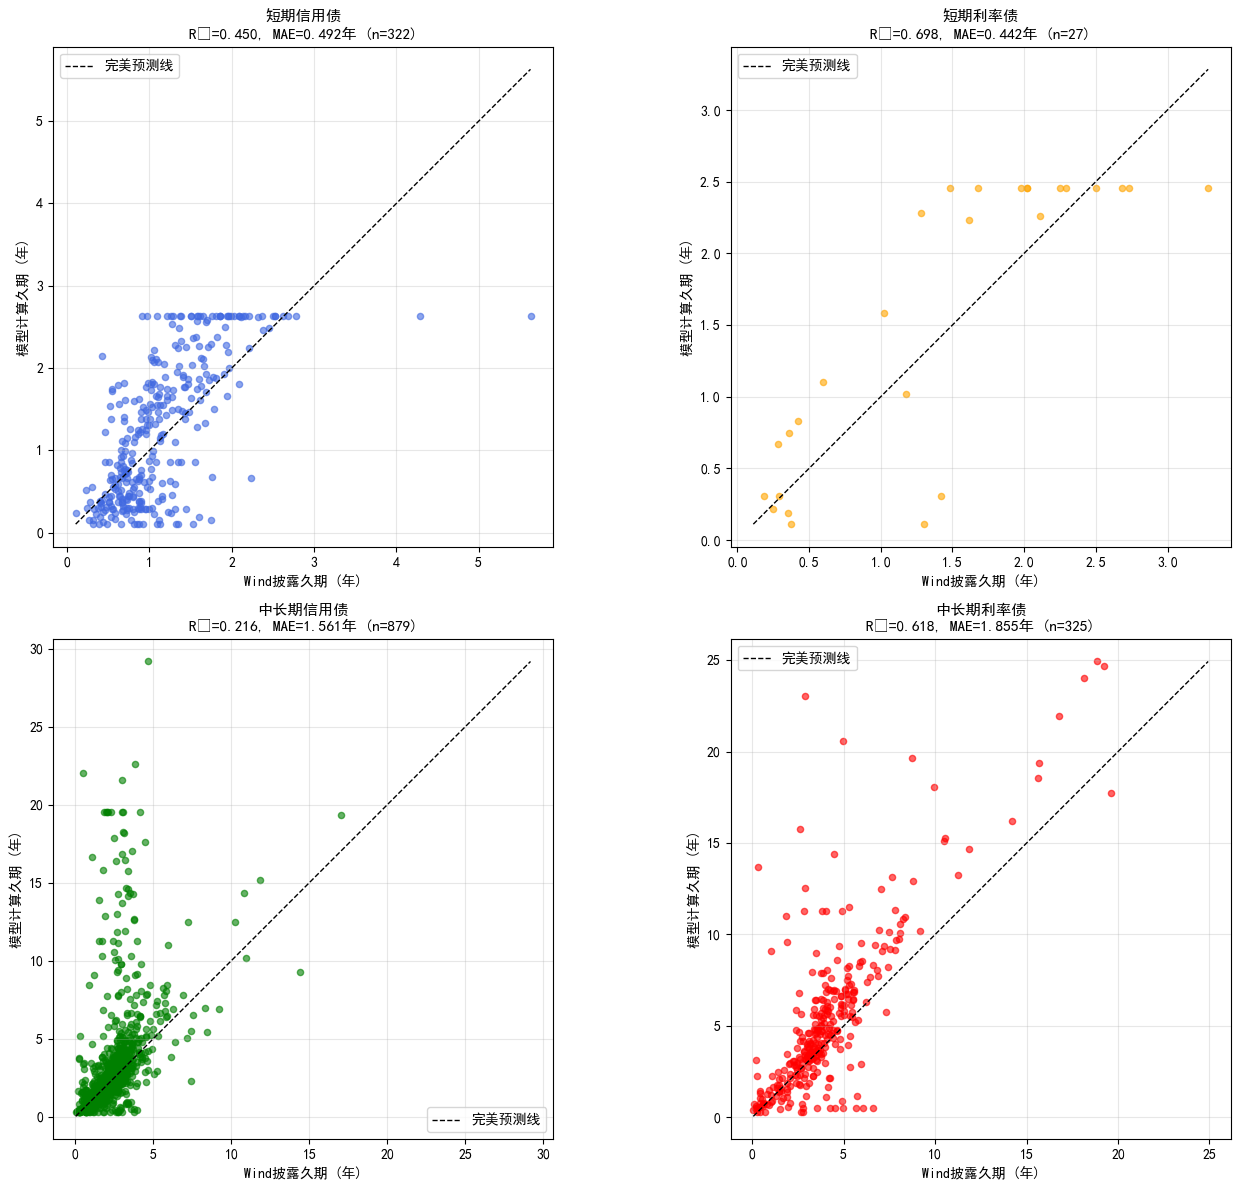

散点图已保存为: ./output/久期验证散点图.png


In [9]:
# 绘制散点图对比
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 定义类型映射
type_map = {
    ('short', 'credit'): ('短期信用债', 'royalblue'),
    ('short', 'rate'): ('短期利率债', 'orange'),
    ('medium_long', 'credit'): ('中长期信用债', 'green'),
    ('medium_long', 'rate'): ('中长期利率债', 'red')
}

for idx, ((fund_type, bond_type), (type_name, color)) in enumerate(type_map.items()):
    ax = axes[idx // 2, idx % 2]
    
    mask = (valid_df['fund_type'] == fund_type) & (valid_df['bond_type'] == bond_type)
    subset = valid_df[mask]
    
    if len(subset) > 0:
        # 散点图
        ax.scatter(subset['wind_duration'], subset['duration'], alpha=0.6, color=color, s=20)
        
        # 45度线（完美预测线）
        min_val = min(subset['wind_duration'].min(), subset['duration'].min())
        max_val = max(subset['wind_duration'].max(), subset['duration'].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1, label='完美预测线')
        
        # 计算R²
        correlation = np.corrcoef(subset['wind_duration'], subset['duration'])[0, 1]
        r_squared = correlation ** 2
        mae = subset['duration_error'].abs().mean()
        
        ax.set_xlabel('Wind披露久期 (年)', fontsize=10)
        ax.set_ylabel('模型计算久期 (年)', fontsize=10)
        ax.set_title(f'{type_name}\nR²={r_squared:.3f}, MAE={mae:.3f}年 (n={len(subset)})', fontsize=11)
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('./output/久期验证散点图.png', dpi=150, bbox_inches='tight')
plt.show()
print("散点图已保存为: ./output/久期验证散点图.png")

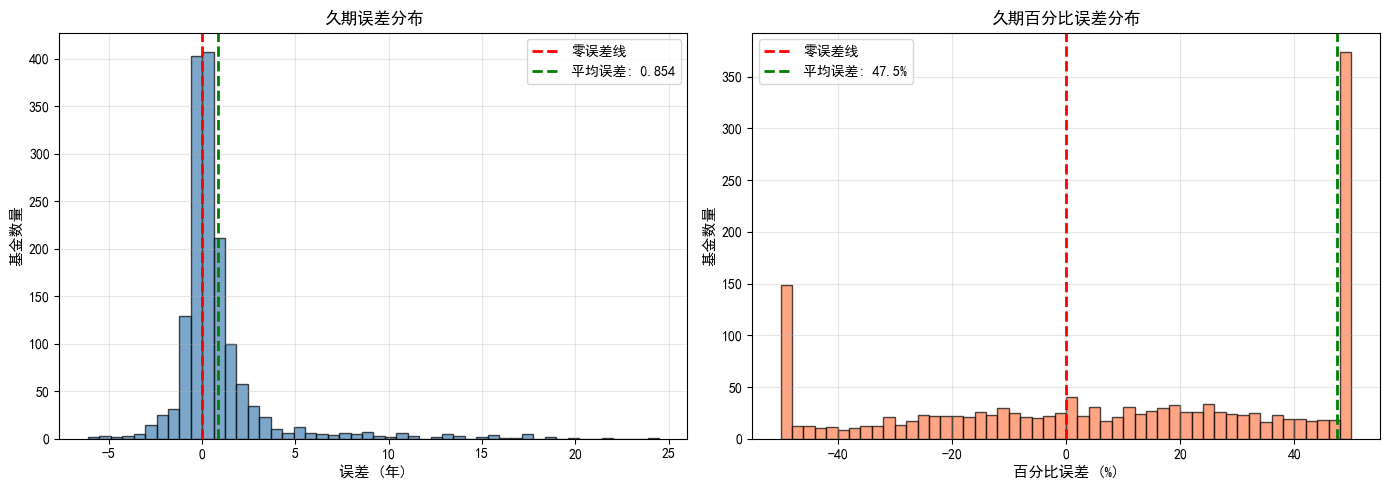

误差分布图已保存为: 误差分布图.png


In [10]:
# 误差分布直方图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 绝对误差分布
axes[0].hist(valid_df['duration_error'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', lw=2, label='零误差线')
axes[0].axvline(valid_df['duration_error'].mean(), color='green', linestyle='--', lw=2, label=f'平均误差: {valid_df["duration_error"].mean():.3f}')
axes[0].set_xlabel('误差 (年)', fontsize=11)
axes[0].set_ylabel('基金数量', fontsize=11)
axes[0].set_title('久期误差分布', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 百分比误差分布（限制在±50%以内以便观察）
pct_error_limited = valid_df['duration_pct_error'].clip(-50, 50)
axes[1].hist(pct_error_limited, bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(0, color='red', linestyle='--', lw=2, label='零误差线')
axes[1].axvline(valid_df['duration_pct_error'].mean(), color='green', linestyle='--', lw=2, label=f'平均误差: {valid_df["duration_pct_error"].mean():.1f}%')
axes[1].set_xlabel('百分比误差 (%)', fontsize=11)
axes[1].set_ylabel('基金数量', fontsize=11)
axes[1].set_title('久期百分比误差分布', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./output/误差分布图.png', dpi=150, bbox_inches='tight')
plt.show()
print("误差分布图已保存为: 误差分布图.png")

In [11]:
# 找出误差最大的基金（可能有问题或需要特殊处理）
print("=== 绝对误差最大的20只基金 ===")
# 先创建绝对误差列
valid_df['duration_error_abs'] = valid_df['duration_error'].abs()
top_errors = valid_df.nlargest(20, 'duration_error_abs')[['fund_code', 'name', 'duration', 'wind_duration', 'duration_error', 'duration_pct_error', 'fund_type', 'bond_type']]
print(top_errors.to_string(index=False))

# 保存到Excel
valid_df.to_excel('./output/久期验证完整结果_20251231.xlsx', index=False)
print(f"\n完整验证结果已保存为: 久期验证完整结果_20251231.xlsx")

=== 绝对误差最大的20只基金 ===
fund_code       name  duration  wind_duration  duration_error  duration_pct_error   fund_type bond_type
009298.OF    英大安惠纯债A 29.172640       4.685234       24.487406          522.650626 medium_long    credit
002811.OF    博时裕顺纯债A 22.022294       0.495858       21.526437         4341.252232 medium_long    credit
003590.OF     建信睿富纯债 23.030550       2.895320       20.135230          695.440674 medium_long      rate
003672.OF      兴业裕华A 22.598414       3.837109       18.761306          488.943824 medium_long    credit
008684.OF      宝盈盈旭A 21.603319       3.010000       18.593319          617.718248 medium_long    credit
000497.OF      财通纯债A 19.495980       1.811701       17.684279          976.114589 medium_long    credit
010836.OF       国泰瑞泰 19.495980       1.932648       17.563332          908.770206 medium_long    credit
001993.OF     博时裕泰纯债 19.495980       2.038903       17.457077          856.199559 medium_long    credit
007557.OF  中加优选中高等级A 19.495980       2.0817

In [12]:
# 生成验证报告摘要
summary = []
summary.append("="*60)
summary.append("久期计算验证报告摘要")
summary.append("="*60)
summary.append(f"验证日期: 2025-12-31")
summary.append(f"总计算基金数: {len(result_df)}")
summary.append(f"有效验证数（有Wind真实久期）: {len(valid_df)}")
summary.append("")
summary.append("整体误差统计:")
summary.append(f"  - 平均绝对误差 (MAE): {valid_df['duration_error'].abs().mean():.4f} 年")
summary.append(f"  - 误差标准差: {valid_df['duration_error'].std():.4f} 年")
summary.append(f"  - 相关系数: {np.corrcoef(valid_df['wind_duration'], valid_df['duration'])[0,1]:.4f}")
summary.append(f"  - R²: {(np.corrcoef(valid_df['wind_duration'], valid_df['duration'])[0,1])**2:.4f}")
summary.append("")
summary.append("按类型统计:")

for fund_type in ['short', 'medium_long']:
    for bond_type in ['credit', 'rate']:
        mask = (valid_df['fund_type'] == fund_type) & (valid_df['bond_type'] == bond_type)
        subset = valid_df[mask]
        
        if len(subset) > 0:
            fund_type_name = '短期' if fund_type == 'short' else '中长期'
            bond_type_name = '信用债' if bond_type == 'credit' else '利率债'
            correlation = np.corrcoef(subset['wind_duration'], subset['duration'])[0,1]
            
            summary.append(f"  {fund_type_name}{bond_type_name} (n={len(subset)}):")
            summary.append(f"    MAE: {subset['duration_error'].abs().mean():.4f}年, R²: {correlation**2:.4f}")

summary.append("="*60)

# 打印报告
print("\n".join(summary))

# 保存报告
with open('./output/验证报告.txt', 'w', encoding='utf-8') as f:
    f.write("\n".join(summary))
print("\n验证报告已保存为: ./output/验证报告.txt")

久期计算验证报告摘要
验证日期: 2025-12-31
总计算基金数: 1564
有效验证数（有Wind真实久期）: 1553

整体误差统计:
  - 平均绝对误差 (MAE): 1.3810 年
  - 误差标准差: 2.8133 年
  - 相关系数: 0.6604
  - R²: 0.4361

按类型统计:
  短期信用债 (n=322):
    MAE: 0.4915年, R²: 0.4502
  短期利率债 (n=27):
    MAE: 0.4419年, R²: 0.6979
  中长期信用债 (n=879):
    MAE: 1.5605年, R²: 0.2157
  中长期利率债 (n=325):
    MAE: 1.8550年, R²: 0.6184

验证报告已保存为: ./output/验证报告.txt


# --- 分别剔除上界/下界基金后重新验证 ---

#### 分别剔除上界/下界基金

In [13]:
# 读取迭代日志，获取触发边界的基金列表
import os

log_file = './output/久期迭代日志_20251231.xlsx'

In [14]:
# 读取迭代详情，分别获取触发上界和下界的基金列表
if os.path.exists(log_file):
    df_detail = pd.read_excel(log_file, sheet_name='迭代详情')
    df_iter = pd.read_excel(log_file, sheet_name='全量汇总')
    print(f"迭代详情读取成功，共 {len(df_detail)} 条记录")
    
    # 统计各基金触发的边界类型（以最后一次触发的类型为准）
    # 只看真正在边界上的轮次（排除 interior 轮）
    df_bnd = df_detail[df_detail['boundary_type'].isin(['upper', 'lower'])].copy()
    
    if len(df_bnd) > 0:
        # 按基金分组，取最后一个边界类型
        last_boundary = df_bnd.sort_values('round').groupby('fund_code')['boundary_type'].last()
        
        upper_funds = set(last_boundary[last_boundary == 'upper'].index.tolist())
        lower_funds = set(last_boundary[last_boundary == 'lower'].index.tolist())
        boundary_funds = upper_funds.union(lower_funds)

        print(f"\n边界类型分布（以最后一次触发为准）：")
        print(f"  触发上界的基金数量: {len(upper_funds)}")
        print(f"  触发下界的基金数量: {len(lower_funds)}")
        print(f"  两者重叠: {len(upper_funds & lower_funds)} （同一基金既触发过上界又触发过下界）")
        
        # 展示一些示例
        print(f"\n触发上界的基金示例（前10只）：")
        sample_upper = list(upper_funds)[:10]
        print(f"  {', '.join(sample_upper)}")
        
        print(f"\n触发下界的基金示例（前10只）：")
        sample_lower = list(lower_funds)[:10]
        print(f"  {', '.join(sample_lower)}")
    else:
        print("没有触发边界的记录")
        upper_funds = set()
        lower_funds = set()
else:
    print("迭代日志文件不存在")
    upper_funds = set()
    lower_funds = set()

# 从验证数据中剔除上界基金
valid_df_no_upper = valid_df[~valid_df['fund_code'].isin(upper_funds)].copy()
print(f"\n剔除上界后数据量: {len(valid_df)} -> {len(valid_df_no_upper)} ({len(valid_df)-len(valid_df_no_upper)} 只)")

# 从验证数据中剔除下界基金
valid_df_no_lower = valid_df[~valid_df['fund_code'].isin(lower_funds)].copy()
print(f"剔除下界后数据量: {len(valid_df)} -> {len(valid_df_no_lower)} ({len(valid_df)-len(valid_df_no_lower)} 只)")

valid_df_no_boundary = valid_df[~valid_df['fund_code'].isin(boundary_funds)].copy()
print(f"剔除所有边界后数据量: {len(valid_df)} -> {len(valid_df_no_boundary)} ({len(valid_df)-len(valid_df_no_boundary)} 只)")

迭代详情读取成功，共 4368 条记录

边界类型分布（以最后一次触发为准）：
  触发上界的基金数量: 701
  触发下界的基金数量: 594
  两者重叠: 0 （同一基金既触发过上界又触发过下界）

触发上界的基金示例（前10只）：
  016426.OF, 019178.OF, 018642.OF, 003999.OF, 021552.OF, 016799.OF, 006609.OF, 380005.OF, 100066.OF, 003668.OF

触发下界的基金示例（前10只）：
  009407.OF, 008785.OF, 000394.OF, 003418.OF, 003571.OF, 020399.OF, 023848.OF, 018880.OF, 000736.OF, 003733.OF

剔除上界后数据量: 1553 -> 858 (695 只)
剔除下界后数据量: 1553 -> 964 (589 只)
剔除所有边界后数据量: 1553 -> 269 (1284 只)


#### 剔除上界/下界后的误差统计对比

In [15]:
# 剔除上界/下界后的误差统计对比
print("=" * 80)
print("剔除上界/下界后的误差统计对比")
print("=" * 80)

# 计算各场景的指标
def calc_metrics(df):
    if len(df) == 0:
        return None
    mae = df['duration_error'].abs().mean()
    std = df['duration_error'].std()
    corr = np.corrcoef(df['wind_duration'], df['duration'])[0, 1]
    r2 = corr ** 2
    return {'n': len(df), 'mae': mae, 'std': std, 'corr': corr, 'r2': r2}

metrics_original = calc_metrics(valid_df)
metrics_no_upper = calc_metrics(valid_df_no_upper)
metrics_no_lower = calc_metrics(valid_df_no_lower)
metrics_no_boundary = calc_metrics(valid_df_no_boundary)

print(f"\n{'场景':<20} {'样本数':>10} {'MAE':>12} {'标准差':>12} {'R²':>12}")
print("-" * 80)
print(f"{'原始数据':<20} {metrics_original['n']:>10} {metrics_original['mae']:>12.4f} {metrics_original['std']:>12.4f} {metrics_original['r2']:>12.4f}")
print(f"{'剔除上界后':<20} {metrics_no_upper['n']:>10} {metrics_no_upper['mae']:>12.4f} {metrics_no_upper['std']:>12.4f} {metrics_no_upper['r2']:>12.4f}")
print(f"{'剔除下界后':<20} {metrics_no_lower['n']:>10} {metrics_no_lower['mae']:>12.4f} {metrics_no_lower['std']:>12.4f} {metrics_no_lower['r2']:>12.4f}")
print(f"{'剔除所有边界后':<20} {metrics_no_boundary['n']:>10} {metrics_no_boundary['mae']:>12.4f} {metrics_no_boundary['std']:>12.4f} {metrics_no_boundary['r2']:>12.4f}")

print("\n" + "=" * 80)
print("变化量分析（相对原始数据）：")
print("-" * 80)

# 计算变化
def calc_change(new_val, old_val):
    return new_val - old_val

mae_change_no_upper = calc_change(metrics_no_upper['mae'], metrics_original['mae'])
mae_change_no_lower = calc_change(metrics_no_lower['mae'], metrics_original['mae'])
mae_change_no_boundary = calc_change(metrics_no_boundary['mae'], metrics_original['mae'])

r2_change_no_upper = calc_change(metrics_no_upper['r2'], metrics_original['r2'])
r2_change_no_lower = calc_change(metrics_no_lower['r2'], metrics_original['r2'])
r2_change_no_boundary = calc_change(metrics_no_boundary['r2'], metrics_original['r2'])

print(f"{'剔除上界':<20} MAE变化: {mae_change_no_upper:+.4f}, R²变化: {r2_change_no_upper:+.4f}")
print(f"{'剔除下界':<20} MAE变化: {mae_change_no_lower:+.4f}, R²变化: {r2_change_no_lower:+.4f}")
print(f"{'剔除所有边界':<20} MAE变化: {mae_change_no_boundary:+.4f}, R²变化: {r2_change_no_boundary:+.4f}")

print("\n" + "=" * 80)
print("结论：")
if mae_change_no_upper < mae_change_no_lower:
    print(f"  • 剔除上界对MAE改善更大（{mae_change_no_upper:+.4f} vs {mae_change_no_lower:+.4f}）")
elif mae_change_no_upper > mae_change_no_lower:
    print(f"  • 剔除下界对MAE改善更大（{mae_change_no_lower:+.4f} vs {mae_change_no_upper:+.4f}）")
else:
    print(f"  • 剔除上界/下界对MAE影响相同")

if r2_change_no_upper > r2_change_no_lower:
    print(f"  • 剔除上界对R²提升更大（{r2_change_no_upper:+.4f} vs {r2_change_no_lower:+.4f}）")
elif r2_change_no_upper < r2_change_no_lower:
    print(f"  • 剔除下界对R²提升更大（{r2_change_no_lower:+.4f} vs {r2_change_no_upper:+.4f}）")
else:
    print(f"  • 剔除上界/下界对R²影响相同")
print("=" * 80)

剔除上界/下界后的误差统计对比

场景                          样本数          MAE          标准差           R²
--------------------------------------------------------------------------------
原始数据                       1553       1.3810       2.8133       0.4361
剔除上界后                       858       0.9916       1.6834       0.6423
剔除下界后                       964       1.6257       3.3177       0.4079
剔除所有边界后                     269       1.0158       1.8990       0.7300

变化量分析（相对原始数据）：
--------------------------------------------------------------------------------
剔除上界                 MAE变化: -0.3894, R²变化: +0.2062
剔除下界                 MAE变化: +0.2447, R²变化: -0.0282
剔除所有边界               MAE变化: -0.3652, R²变化: +0.2939

结论：
  • 剔除上界对MAE改善更大（-0.3894 vs +0.2447）
  • 剔除上界对R²提升更大（+0.2062 vs -0.0282）


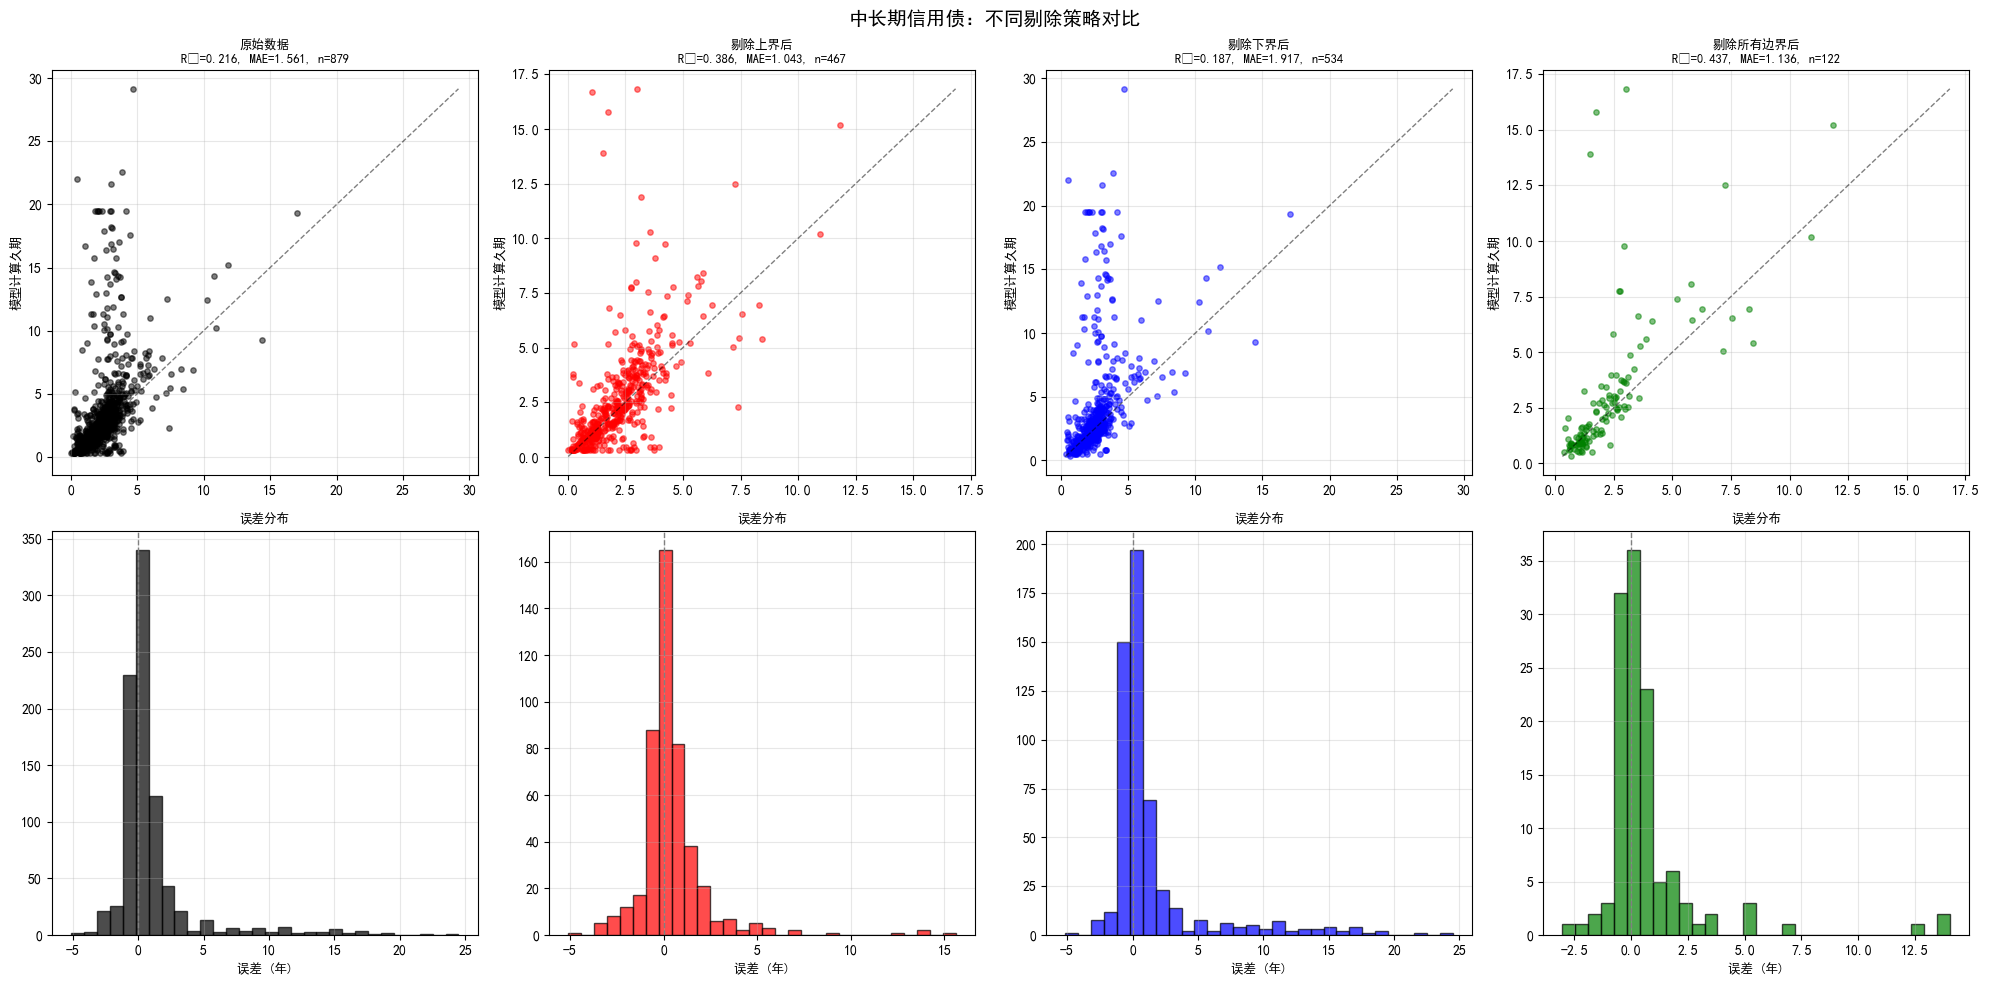

对比图已保存为: ./output/上界下界剔除对比图.png


In [16]:
# 可视化对比：4种场景下的散点图
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

scenarios = [
    ('原始数据', valid_df, 'black'),
    ('剔除上界后', valid_df_no_upper, 'red'),
    ('剔除下界后', valid_df_no_lower, 'blue'),
    ('剔除所有边界后', valid_df_no_boundary, 'green')
]

# 只展示中长期信用债作为示例（数量最多）
fund_type, bond_type = 'medium_long', 'credit'
fund_type_name = '中长期'
bond_type_name = '信用债'

for col, (scenario_name, scenario_df, color) in enumerate(scenarios):
    mask = (scenario_df['fund_type'] == fund_type) & (scenario_df['bond_type'] == bond_type)
    subset = scenario_df[mask]
    
    for row in range(2):
        ax = axes[row, col]
        
        if row == 0:
            # 散点图
            if len(subset) > 0:
                ax.scatter(subset['wind_duration'], subset['duration'], alpha=0.5, color=color, s=15)
                min_val = min(subset['wind_duration'].min(), subset['duration'].min())
                max_val = max(subset['wind_duration'].max(), subset['duration'].max())
                ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1, alpha=0.5)
                correlation = np.corrcoef(subset['wind_duration'], subset['duration'])[0, 1]
                r_squared = correlation ** 2
                mae = subset['duration_error'].abs().mean()
                ax.set_title(f'{scenario_name}\nR²={r_squared:.3f}, MAE={mae:.3f}, n={len(subset)}', fontsize=9)
            ax.set_ylabel('模型计算久期', fontsize=9)
        else:
            # 误差分布
            if len(subset) > 0:
                ax.hist(subset['duration_error'], bins=30, edgecolor='black', alpha=0.7, color=color)
                ax.axvline(0, color='gray', linestyle='--', lw=1)
                ax.set_title(f'误差分布', fontsize=9)
            ax.set_xlabel('误差 (年)', fontsize=9)
        
        ax.grid(True, alpha=0.3)

fig.suptitle(f'{fund_type_name}{bond_type_name}：不同剔除策略对比', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./output/上界下界剔除对比图.png', dpi=150, bbox_inches='tight')
plt.show()
print("对比图已保存为: ./output/上界下界剔除对比图.png")

# --- 剔除触碰上边界的点后重新验证 ---

#### 剔除边界后的整体误差统计

#### 剔除边界后的分类统计

In [17]:
valid_df_no_boundary = valid_df_no_upper.copy()

In [18]:
# 整体误差统计（剔除触碰边界后）
print("=" * 60)
print("剔除触碰边界后的整体误差统计")
print("=" * 60)
print(f"有效数据数量: {len(valid_df_no_boundary)}")
print(f"\n整体误差统计:")
print(f"平均绝对误差 (MAE): {valid_df_no_boundary['duration_error'].abs().mean():.4f} 年")
print(f"误差标准差: {valid_df_no_boundary['duration_error'].std():.4f} 年")
print(f"误差中位数: {valid_df_no_boundary['duration_error'].median():.4f} 年")
print(f"\n误差分布:")
print(valid_df_no_boundary['duration_error'].describe())

print(f"\n平均百分比误差: {valid_df_no_boundary['duration_pct_error'].mean():.2f}%")
print(f"百分比误差中位数: {valid_df_no_boundary['duration_pct_error'].median():.2f}%")

# 计算R²
correlation_no_bnd = np.corrcoef(valid_df_no_boundary['wind_duration'], valid_df_no_boundary['duration'])[0, 1]
r_squared_no_bnd = correlation_no_bnd ** 2
print(f"\n相关系数: {correlation_no_bnd:.4f}")
print(f"R²: {r_squared_no_bnd:.4f}")

剔除触碰边界后的整体误差统计
有效数据数量: 858

整体误差统计:
平均绝对误差 (MAE): 0.9916 年
误差标准差: 1.6834 年
误差中位数: 0.1698 年

误差分布:
count    858.000000
mean       0.473142
std        1.683421
min       -5.097628
25%       -0.291816
50%        0.169819
75%        0.894560
max       15.597875
Name: duration_error, dtype: float64

平均百分比误差: 32.00%
百分比误差中位数: 12.51%

相关系数: 0.8015
R²: 0.6423


#### 剔除边界后的可视化输出

In [19]:
# 按类型分组统计（剔除触碰边界后）
print("=" * 60)
print("剔除触碰边界后的分类统计")
print("=" * 60 + "\n")

# 统计各类基金剔除前后的数量变化
print("各类基金数量变化:")
print("-" * 60)
print(f"{'类型':<20} {'原始数量':>10} {'剔除边界':>10} {'剔除比例':>10}")
print("-" * 60)

for fund_type in ['short', 'medium_long']:
    for bond_type in ['credit', 'rate']:
        mask = (valid_df['fund_type'] == fund_type) & (valid_df['bond_type'] == bond_type)
        mask_no_bnd = (valid_df_no_boundary['fund_type'] == fund_type) & (valid_df_no_boundary['bond_type'] == bond_type)
        
        original_count = mask.sum()
        no_boundary_count = mask_no_bnd.sum()
        removed_pct = (original_count - no_boundary_count) / original_count * 100 if original_count > 0 else 0
        
        fund_type_name = '短期' if fund_type == 'short' else '中长期'
        bond_type_name = '信用债' if bond_type == 'credit' else '利率债'
        type_label = f"{fund_type_name}{bond_type_name}"
        
        print(f"{type_label:<20} {original_count:>10} {no_boundary_count:>10} {removed_pct:>9.1f}%")

print("\n" + "=" * 60)
print("各类基金误差统计（剔除边界后）")
print("=" * 60 + "\n")

for fund_type in ['short', 'medium_long']:
    for bond_type in ['credit', 'rate']:
        mask = (valid_df_no_boundary['fund_type'] == fund_type) & (valid_df_no_boundary['bond_type'] == bond_type)
        subset = valid_df_no_boundary[mask]
        
        if len(subset) > 0:
            fund_type_name = '短期' if fund_type == 'short' else '中长期'
            bond_type_name = '信用债' if bond_type == 'credit' else '利率债'
            correlation = np.corrcoef(subset['wind_duration'], subset['duration'])[0, 1]
            
            print(f"{fund_type_name}{bond_type_name} (n={len(subset)}):")
            print(f"  平均绝对误差: {subset['duration_error'].abs().mean():.4f} 年")
            print(f"  误差标准差: {subset['duration_error'].std():.4f} 年")
            print(f"  平均计算久期: {subset['duration'].mean():.4f} 年")
            print(f"  平均Wind久期: {subset['wind_duration'].mean():.4f} 年")
            print(f"  R²: {correlation**2:.4f}")
            print()

剔除触碰边界后的分类统计

各类基金数量变化:
------------------------------------------------------------
类型                         原始数量       剔除边界       剔除比例
------------------------------------------------------------
短期信用债                       322        200      37.9%
短期利率债                        27         10      63.0%
中长期信用债                      879        467      46.9%
中长期利率债                      325        181      44.3%

各类基金误差统计（剔除边界后）

短期信用债 (n=200):
  平均绝对误差: 0.4177 年
  误差标准差: 0.5285 年
  平均计算久期: 0.8597 年
  平均Wind久期: 0.9128 年
  R²: 0.2982

短期利率债 (n=10):
  平均绝对误差: 0.4976 年
  误差标准差: 0.6831 年
  平均计算久期: 0.5768 年
  平均Wind久期: 0.6332 年
  R²: 0.0996

中长期信用债 (n=467):
  平均绝对误差: 1.0425 年
  误差标准差: 1.9076 年
  平均计算久期: 2.6789 年
  平均Wind久期: 2.2426 年
  R²: 0.3858

中长期利率债 (n=181):
  平均绝对误差: 1.5218 年
  误差标准差: 1.7062 年
  平均计算久期: 5.1087 年
  平均Wind久期: 3.9295 年
  R²: 0.7472



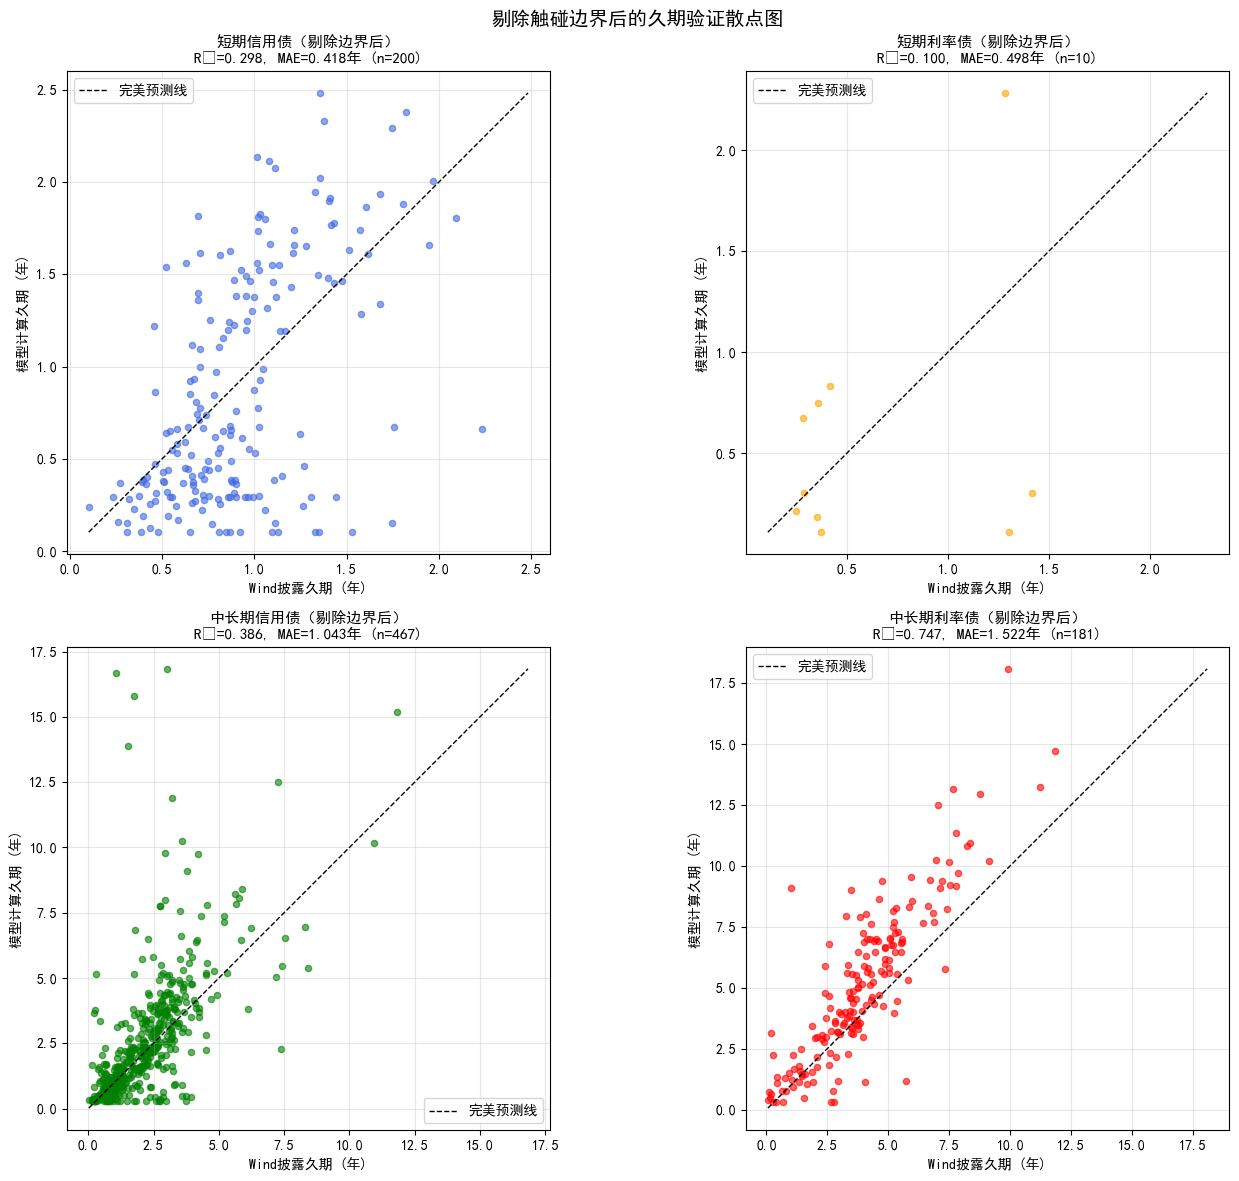

散点图已保存为: ./output/久期验证散点图_剔除边界.png


In [20]:
# 绘制散点图对比（剔除触碰边界后）
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 定义类型映射
type_map = {
    ('short', 'credit'): ('短期信用债', 'royalblue'),
    ('short', 'rate'): ('短期利率债', 'orange'),
    ('medium_long', 'credit'): ('中长期信用债', 'green'),
    ('medium_long', 'rate'): ('中长期利率债', 'red')
}

for idx, ((fund_type, bond_type), (type_name, color)) in enumerate(type_map.items()):
    ax = axes[idx // 2, idx % 2]
    
    mask = (valid_df_no_boundary['fund_type'] == fund_type) & (valid_df_no_boundary['bond_type'] == bond_type)
    subset = valid_df_no_boundary[mask]
    
    if len(subset) > 0:
        # 散点图
        ax.scatter(subset['wind_duration'], subset['duration'], alpha=0.6, color=color, s=20)
        
        # 45度线（完美预测线）
        min_val = min(subset['wind_duration'].min(), subset['duration'].min())
        max_val = max(subset['wind_duration'].max(), subset['duration'].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1, label='完美预测线')
        
        # 计算R²
        correlation = np.corrcoef(subset['wind_duration'], subset['duration'])[0, 1]
        r_squared = correlation ** 2
        mae = subset['duration_error'].abs().mean()
        
        ax.set_xlabel('Wind披露久期 (年)', fontsize=10)
        ax.set_ylabel('模型计算久期 (年)', fontsize=10)
        ax.set_title(f'{type_name}（剔除边界后）\nR²={r_squared:.3f}, MAE={mae:.3f}年 (n={len(subset)})', fontsize=11)
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal', adjustable='box')

plt.suptitle('剔除触碰边界后的久期验证散点图', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./output/久期验证散点图_剔除边界.png', dpi=150, bbox_inches='tight')
plt.show()
print("散点图已保存为: ./output/久期验证散点图_剔除边界.png")

#### 对比总结报告

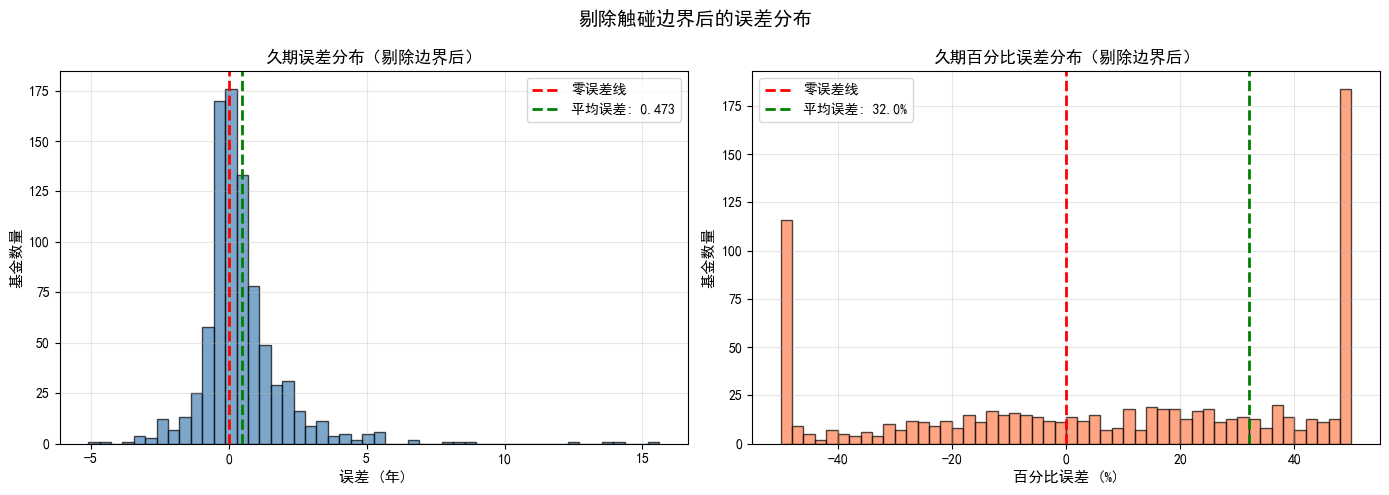

误差分布图已保存为: ./output/误差分布图_剔除边界.png


In [21]:
# 误差分布直方图（剔除触碰边界后）
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 绝对误差分布
axes[0].hist(valid_df_no_boundary['duration_error'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', lw=2, label='零误差线')
axes[0].axvline(valid_df_no_boundary['duration_error'].mean(), color='green', linestyle='--', lw=2, label=f'平均误差: {valid_df_no_boundary["duration_error"].mean():.3f}')
axes[0].set_xlabel('误差 (年)', fontsize=11)
axes[0].set_ylabel('基金数量', fontsize=11)
axes[0].set_title('久期误差分布（剔除边界后）', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 百分比误差分布（限制在±50%以内以便观察）
pct_error_limited = valid_df_no_boundary['duration_pct_error'].clip(-50, 50)
axes[1].hist(pct_error_limited, bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(0, color='red', linestyle='--', lw=2, label='零误差线')
axes[1].axvline(valid_df_no_boundary['duration_pct_error'].mean(), color='green', linestyle='--', lw=2, label=f'平均误差: {valid_df_no_boundary["duration_pct_error"].mean():.1f}%')
axes[1].set_xlabel('百分比误差 (%)', fontsize=11)
axes[1].set_ylabel('基金数量', fontsize=11)
axes[1].set_title('久期百分比误差分布（剔除边界后）', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('剔除触碰边界后的误差分布', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./output/误差分布图_剔除边界.png', dpi=150, bbox_inches='tight')
plt.show()
print("误差分布图已保存为: ./output/误差分布图_剔除边界.png")

In [22]:
# 生成对比总结报告
print("=" * 70)
print("剔除触碰边界前后的验证结果对比")
print("=" * 70)

# 整体对比
print("\n【整体指标对比】")
print("-" * 70)
print(f"{'指标':<25} {'剔除前':>15} {'剔除后':>15} {'变化':>15}")
print("-" * 70)

n_before = len(valid_df)
n_after = len(valid_df_no_boundary)
mae_before = valid_df['duration_error'].abs().mean()
mae_after = valid_df_no_boundary['duration_error'].abs().mean()
std_before = valid_df['duration_error'].std()
std_after = valid_df_no_boundary['duration_error'].std()
corr_before = np.corrcoef(valid_df['wind_duration'], valid_df['duration'])[0, 1]
corr_after = np.corrcoef(valid_df_no_boundary['wind_duration'], valid_df_no_boundary['duration'])[0, 1]
r2_before = corr_before ** 2
r2_after = corr_after ** 2

print(f"{'样本数量':<25} {n_before:>15} {n_after:>15} {n_before-n_after:>14}")
print(f"{'平均绝对误差 (MAE)':<25} {mae_before:>15.4f} {mae_after:>15.4f} {mae_after-mae_before:>14.4f}")
print(f"{'误差标准差':<25} {std_before:>15.4f} {std_after:>15.4f} {std_after-std_before:>14.4f}")
print(f"{'相关系数':<25} {corr_before:>15.4f} {corr_after:>15.4f} {corr_after-corr_before:>14.4f}")
print(f"{'R²':<25} {r2_before:>15.4f} {r2_after:>15.4f} {r2_after-r2_before:>14.4f}")

# 分类对比
print("\n【分类指标对比】")
print("-" * 70)
print(f"{'类型':<20} {'MAE前':>10} {'MAE后':>10} {'MAE变化':>10} {'R²前':>10} {'R²后':>10} {'R²变化':>10}")
print("-" * 70)

for fund_type in ['short', 'medium_long']:
    for bond_type in ['credit', 'rate']:
        mask_before = (valid_df['fund_type'] == fund_type) & (valid_df['bond_type'] == bond_type)
        mask_after = (valid_df_no_boundary['fund_type'] == fund_type) & (valid_df_no_boundary['bond_type'] == bond_type)
        
        subset_before = valid_df[mask_before]
        subset_after = valid_df_no_boundary[mask_after]
        
        if len(subset_before) > 0 and len(subset_after) > 0:
            fund_type_name = '短期' if fund_type == 'short' else '中长期'
            bond_type_name = '信用债' if bond_type == 'credit' else '利率债'
            type_label = f"{fund_type_name}{bond_type_name}"
            
            mae_b = subset_before['duration_error'].abs().mean()
            mae_a = subset_after['duration_error'].abs().mean()
            corr_b = np.corrcoef(subset_before['wind_duration'], subset_before['duration'])[0, 1]
            corr_a = np.corrcoef(subset_after['wind_duration'], subset_after['duration'])[0, 1]
            r2_b = corr_b ** 2
            r2_a = corr_a ** 2
            
            print(f"{type_label:<20} {mae_b:>10.4f} {mae_a:>10.4f} {mae_a-mae_b:>9.4f} {r2_b:>10.3f} {r2_a:>10.3f} {r2_a-r2_b:>9.3f}")

print("\n" + "=" * 70)
print("结论：")
print(f"  • 剔除触碰边界的基金后，MAE {'改善' if mae_after < mae_before else '变差'}: {mae_after-mae_before:+.4f} 年")
print(f"  • 剔除触碰边界的基金后，R² {'提升' if r2_after > r2_before else '下降'}: {r2_after-r2_before:+.4f}")
print("=" * 70)

# 保存对比报告
with open('./output/验证报告_剔除边界对比.txt', 'w', encoding='utf-8') as f:
    f.write("=" * 70 + "\n")
    f.write("剔除触碰边界前后的验证结果对比\n")
    f.write("=" * 70 + "\n\n")
    
    f.write("【整体指标对比】\n")
    f.write("-" * 70 + "\n")
    f.write(f"{'指标':<25} {'剔除前':>15} {'剔除后':>15} {'变化':>15}\n")
    f.write("-" * 70 + "\n")
    f.write(f"{'样本数量':<25} {n_before:>15} {n_after:>15} {n_before-n_after:>14}\n")
    f.write(f"{'平均绝对误差 (MAE)':<25} {mae_before:>15.4f} {mae_after:>15.4f} {mae_after-mae_before:>14.4f}\n")
    f.write(f"{'误差标准差':<25} {std_before:>15.4f} {std_after:>15.4f} {std_after-std_before:>14.4f}\n")
    f.write(f"{'相关系数':<25} {corr_before:>15.4f} {corr_after:>15.4f} {corr_after-corr_before:>14.4f}\n")
    f.write(f"{'R²':<25} {r2_before:>15.4f} {r2_after:>15.4f} {r2_after-r2_before:>14.4f}\n")
    
print("\n对比报告已保存为: ./output/验证报告_剔除边界对比.txt")

剔除触碰边界前后的验证结果对比

【整体指标对比】
----------------------------------------------------------------------
指标                                    剔除前             剔除后              变化
----------------------------------------------------------------------
样本数量                                 1553             858            695
平均绝对误差 (MAE)                       1.3810          0.9916        -0.3894
误差标准差                              2.8133          1.6834        -1.1299
相关系数                               0.6604          0.8015         0.1411
R²                                 0.4361          0.6423         0.2062

【分类指标对比】
----------------------------------------------------------------------
类型                         MAE前       MAE后      MAE变化        R²前        R²后       R²变化
----------------------------------------------------------------------
短期信用债                    0.4915     0.4177   -0.0738      0.450      0.298    -0.152
短期利率债                    0.4419     0.4976    0.0557      0.698      

In [23]:
# 按类型分组统计
print("=== 按基金类型和债券类型统计 ===\n")

for fund_type in ['short', 'medium_long']:
    for bond_type in ['credit', 'rate']:
        mask = (valid_df_no_boundary['fund_type'] == fund_type) & (valid_df_no_boundary['bond_type'] == bond_type)
        subset = valid_df_no_boundary[mask]
        
        if len(subset) > 0:
            fund_type_name = '短期' if fund_type == 'short' else '中长期'
            bond_type_name = '信用债' if bond_type == 'credit' else '利率债'
            
            print(f"{fund_type_name}{bond_type_name} (n={len(subset)}):")
            print(f"  平均绝对误差: {subset['duration_error'].abs().mean():.4f} 年")
            print(f"  误差标准差: {subset['duration_error'].std():.4f} 年")
            print(f"  平均计算久期: {subset['duration'].mean():.4f} 年")
            print(f"  平均Wind久期: {subset['wind_duration'].mean():.4f} 年")
            print()

=== 按基金类型和债券类型统计 ===

短期信用债 (n=200):
  平均绝对误差: 0.4177 年
  误差标准差: 0.5285 年
  平均计算久期: 0.8597 年
  平均Wind久期: 0.9128 年

短期利率债 (n=10):
  平均绝对误差: 0.4976 年
  误差标准差: 0.6831 年
  平均计算久期: 0.5768 年
  平均Wind久期: 0.6332 年

中长期信用债 (n=467):
  平均绝对误差: 1.0425 年
  误差标准差: 1.9076 年
  平均计算久期: 2.6789 年
  平均Wind久期: 2.2426 年

中长期利率债 (n=181):
  平均绝对误差: 1.5218 年
  误差标准差: 1.7062 年
  平均计算久期: 5.1087 年
  平均Wind久期: 3.9295 年

